# Clase 02 — Del Insight a los Datos
### Análisis descriptivo, diagnóstico y predictivo

 **Ciclo Magistral · Inteligencia de Datos: Análisis e IA Aplicada · 2026**  
 Mara Destefanis · Mgter. Ciencia de Datos · Lic. Comunicación Social




### Información del Dataset

**Dataset:** Avocado Prices and Sales Volume 2015-2023  
Fuente: https://www.kaggle.com/datasets/vakhariapujan/avocado-prices-and-sales-volume-2015-2023  
Archivos en: `Datos/` dentro del directorio de sesión.

### 0. Stack Tecnológico

In [1]:
# Preliminares 
import warnings
warnings.filterwarnings('ignore')

# Paquetes instalados 
import kagglehub
import os
import pandas as pd 
import numpy as np


# Visualización 

from IPython.display import display, HTML
from pathlib import Path
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import matplotlib.lines     as mlines
import seaborn              as sns


# ── Paleta personalizada ──────────────────────────────────────────────────────
PALETA = {
    "hueso":       "#F2EFE4",   # fondo suave
    "oliva":       "#7C8C5E",   # color principal — paltas :)
    "tierra":      "#A0785A",   # acento cálido
    "musgo":       "#4F6347",   # oscuro natural
    "pizarra":     "#5A6472",   # neutro azulado
    "crema":       "#D9D2C0",   # secundario claro
    "ink":         "#2C2C2C",   # texto
}

# Lista ordenada para facetados multi-serie

COLORES_SEQ = [
    PALETA["oliva"],
    PALETA["tierra"],
    PALETA["pizarra"],
    PALETA["musgo"],
    PALETA["crema"],
]

# ── rcParams globales ─────────────────────────────────────────────────────────
sns.set_theme(style="ticks")   # base limpia, sin grid horizontal por defecto

plt.rcParams.update({
    "figure.dpi":           130,
    "figure.facecolor":     "white",
    "axes.facecolor":       "white",
    "axes.edgecolor":       PALETA["ink"],
    "axes.linewidth":       0.7,
    "axes.spines.top":      False,    # sin borde superior
    "axes.spines.right":    False,    # sin borde derecho — look limpio
    "axes.titlesize":       11,
    "axes.titleweight":     "regular",
    "axes.labelsize":       9,
    "axes.labelcolor":      PALETA["ink"],
    "xtick.labelsize":      8,
    "ytick.labelsize":      8,
    "xtick.color":          PALETA["ink"],
    "ytick.color":          PALETA["ink"],
    "grid.color":           PALETA["crema"],
    "grid.linewidth":       0.5,
    "grid.linestyle":       "--",
    "legend.fontsize":      8,
    "legend.frameon":       False,
    "font.family":          "serif",
    "text.color":           PALETA["ink"],
})

# Display numérico
pd.set_option("display.max_columns",  None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Estilo visual cargado.")


Estilo visual cargado.


## 1. Carga de datos

In [2]:
# Descarga 

path = kagglehub.dataset_download("vakhariapujan/avocado-prices-and-sales-volume-2015-2023")
print("Path to dataset files:", path) # Lo haremos directamente desde el sitio. 

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\vakhariapujan\avocado-prices-and-sales-volume-2015-2023\versions\3


In [3]:
print(os.listdir(r"C:\Users\ASUS\.cache\kagglehub\datasets\vakhariapujan\avocado-prices-and-sales-volume-2015-2023\versions\3"))


['Avocado_HassAvocadoBoard_20152023v1.0.1.csv']


In [4]:

palta = pd.read_csv(os.path.join(path, "Avocado_HassAvocadoBoard_20152023v1.0.1.csv"))

#### Observaciones de los datos

**HAB hace una distinción entre bolsas y a granel.**
A granel generalmente significa que las paltas se venden como piezas individuales y son fácilmente distinguibles por su código PLU. Por eso, el PLU se refiere a una venta a granel. 
Por otro lado, las bolsas indican un envase pre-empaquetado que contiene un número variable de paltas de distintos tipos de PLU. Por ejemplo, un paquete de seis paltas puede tener 2 unidades del PLU 4046, 3 del PLU 4770 y 1 del PLU 4225. 
Es decir, las ventas en bolsa no permiten desagregar las ventas por PLU individual.

Con esto las columnas 4046, 4770, 4225 (los PLU) no suman exactamente el Total Volume cuando hay ventas en bolsa de por medio.

**Otras observaciones:** 

- Los datos de PLU son agregados de múltiples puntos de venta por lo cual se promedian o consolidan los registros por eso quedan en decimal aunque es el peso en libras:

- Total Volumen también  pero sin PLUS desagregados.




In [5]:
# Chequeo del data set

palta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53415 entries, 0 to 53414
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          53415 non-null  object 
 1   AveragePrice  53415 non-null  float64
 2   TotalVolume   53415 non-null  float64
 3   plu4046       53415 non-null  float64
 4   plu4225       53415 non-null  float64
 5   plu4770       53415 non-null  float64
 6   TotalBags     53415 non-null  float64
 7   SmallBags     41025 non-null  float64
 8   LargeBags     41025 non-null  float64
 9   XLargeBags    41025 non-null  float64
 10  type          53415 non-null  object 
 11  region        53415 non-null  object 
dtypes: float64(9), object(3)
memory usage: 4.9+ MB


### 2- Limpieza Transformación Datos 

In [6]:
# Nulos 

print("\n== CAMPOS NULOS=====\n") 

nulos = palta.isnull().sum()
print(pd.DataFrame({'nulos': nulos, '%':(nulos/len(palta)*100).round(2)}))


== CAMPOS NULOS=====

              nulos     %
Date              0  0.00
AveragePrice      0  0.00
TotalVolume       0  0.00
plu4046           0  0.00
plu4225           0  0.00
plu4770           0  0.00
TotalBags         0  0.00
SmallBags     12390 23.20
LargeBags     12390 23.20
XLargeBags    12390 23.20
type              0  0.00
region            0  0.00


In [7]:
# Vista rápida — primeras y últimas filas

display(palta.head(3))
display(palta.tail(3))

,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
0,2015-01-04,1.22,"40,873.28","2,819.50","28,287.42",49.90,"9,716.46","9,186.93",529.53,0.00,conventional,Albany
1,2015-01-04,1.79,"1,373.95",57.42,153.88,0.00,"1,162.65","1,162.65",0.00,0.00,organic,Albany
2,2015-01-04,1.00,"435,021.49","364,302.39","23,821.16",82.15,"46,815.79","16,707.15","30,108.64",0.00,conventional,Atlanta


,Date,AveragePrice,TotalVolume,plu4046,plu4225,plu4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,region
53412,2023-12-03,1.62,"34,834.86","15,182.42","1,211.38",0.00,"18,075.66",NaN,NaN,NaN,organic,WestTexNewMexico
53413,2023-12-03,1.25,"2,942.83","1,058.54",7.46,0.00,"1,779.19",NaN,NaN,NaN,organic,Wichita
53414,2023-12-03,1.48,"2,010,020.72","271,808.32","274,480.64",63.43,"1,364,514.02",NaN,NaN,NaN,organic,TotalUS


In [8]:

palta = palta.drop(columns=["SmallBags", "LargeBags", "XLargeBags"])


In [9]:
palta.shape

(53415, 9)

In [10]:
palta.columns.tolist()

['Date',
 'AveragePrice',
 'TotalVolume',
 'plu4046',
 'plu4225',
 'plu4770',
 'TotalBags',
 'type',
 'region']

In [11]:
palta["type"].value_counts()

type
conventional    26709
organic         26706
Name: count, dtype: int64

In [12]:
# Formatos 

palta['Date'] = pd.to_datetime(palta['Date'])
palta['type'] = palta['type'].astype('category')
palta.dtypes

Date            datetime64[ns]
AveragePrice           float64
TotalVolume            float64
plu4046                float64
plu4225                float64
plu4770                float64
TotalBags              float64
type                  category
region                  object
dtype: object

In [13]:
# El formato region si bien deberíamos pasar a categórico analizamos 
# previamente 

palta["region"].value_counts()

region
Albany                  932
Sacramento              932
Northeast               932
Atlanta                 932
Orlando                 932
Philadelphia            932
PhoenixTucson           932
Pittsburgh              932
Plains                  932
Portland                932
RaleighGreensboro       932
RichmondNorfolk         932
Roanoke                 932
SanDiego                932
NewOrleans              932
SanFrancisco            932
Seattle                 932
SouthCarolina           932
SouthCentral            932
Southeast               932
Spokane                 932
StLouis                 932
Syracuse                932
Tampa                   932
TotalUS                 932
West                    932
NewYork                 932
NorthernNewEngland      932
Nashville               932
Detroit                 932
BaltimoreWashington     932
Boise                   932
Boston                  932
BuffaloRochester        932
California              932
Charlotte    

In [14]:
# Limpieza geografica 

# Mapeo ciudad → región según Hass Avocado Board
CIUDAD_REGION = {
    "Albany":               "Northeast",
    "Atlanta":              "Southeast",
    "BaltimoreWashington":  "Midsouth",
    "Boise":                "West",
    "Boston":               "Northeast",
    "BuffaloRochester":     "Northeast",
    "Charlotte":            "Southeast",
    "Chicago":              "GreatLakes",
    "CincinnatiDayton":     "GreatLakes",
    "Columbus":             "GreatLakes",
    "DallasFtWorth":        "SouthCentral",
    "Denver":               "Plains",
    "Detroit":              "GreatLakes",
    "GrandRapids":          "GreatLakes",
    "HarrisburgScranton":   "Northeast",
    "HartfordSpringfield":  "Northeast",
    "Houston":              "SouthCentral",
    "Indianapolis":         "GreatLakes",
    "Jacksonville":         "Southeast",
    "LasVegas":             "West",
    "LosAngeles":           "California",
    "Louisville":           "Midsouth",
    "MiamiFtLauderdale":    "Southeast",
    "Nashville":            "Midsouth",
    "NewOrleansMobile":     "SouthCentral",
    "NewYork":              "Northeast",
    "NorthernNewEngland":   "Northeast",
    "Orlando":              "Southeast",
    "Philadelphia":         "Northeast",
    "PhoenixTucson":        "West",
    "Pittsburgh":           "Northeast",
    "Portland":             "West",
    "RaleighGreensboro":    "Southeast",
    "RichmondNorfolk":      "Midsouth",
    "Roanoke":              "Midsouth",
    "Sacramento":           "California",
    "SanDiego":             "California",
    "SanFrancisco":         "California",
    "Seattle":              "West",
    "SouthCarolina":        "Southeast",
    "Spokane":              "West",
    "StLouis":              "Plains",
    "Syracuse":             "Northeast",
    "Tampa":                "Southeast",
    "WestTexNewMexico":     "SouthCentral",
}

REGIONES = ["California", "West", "Plains", "SouthCentral",
            "Southeast", "Midsouth", "GreatLakes", "Northeast"]

# Construir dataset enriquecido
palta_full = palta[palta["region"] != "TotalUS"].copy()

palta_full["ciudad"]  = palta_full["region"].where(~palta_full["region"].isin(REGIONES), None)
palta_full["region_geo"] = palta_full["region"].apply(
    lambda r: r if r in REGIONES else CIUDAD_REGION.get(r, r)
)

# Verificar
print(palta_full[["region", "ciudad", "region_geo"]].drop_duplicates().sort_values("region_geo"))

                     region                ciudad            region_geo
16959  BirminghamMontgomery  BirminghamMontgomery  BirminghamMontgomery
84             SanFrancisco          SanFrancisco            California
82                 SanDiego              SanDiego            California
12               California                  None            California
80               Sacramento            Sacramento            California
44               LosAngeles            LosAngeles            California
26                  Detroit               Detroit            GreatLakes
16                  Chicago               Chicago            GreatLakes
18         CincinnatiDayton      CincinnatiDayton            GreatLakes
20                 Columbus              Columbus            GreatLakes
38             Indianapolis          Indianapolis            GreatLakes
30               GreatLakes                  None            GreatLakes
28              GrandRapids           GrandRapids            Gre

In [15]:
palta_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52483 entries, 0 to 53413
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          52483 non-null  datetime64[ns]
 1   AveragePrice  52483 non-null  float64       
 2   TotalVolume   52483 non-null  float64       
 3   plu4046       52483 non-null  float64       
 4   plu4225       52483 non-null  float64       
 5   plu4770       52483 non-null  float64       
 6   TotalBags     52483 non-null  float64       
 7   type          52483 non-null  category      
 8   region        52483 non-null  object        
 9   ciudad        45027 non-null  object        
 10  region_geo    52483 non-null  object        
dtypes: category(1), datetime64[ns](1), float64(6), object(3)
memory usage: 4.5+ MB


In [16]:
# Total: 
nulls = palta_full["ciudad"].isnull().sum()
print(f"Nulos: {nulls} — {nulls / len(palta_full) * 100:.1f}%")

Nulos: 7456 — 14.2%


In [17]:
# cambio nombres de las variables 

palta_full = palta_full.rename(columns={
    'Date' : 'Fecha',
    'AveragePrice' : 'PrecioPromedio',
    'TotalVolume' : 'TotalVolume',
    'plu4046' : 'Palta_Normal',
    'plu4225' : 'Palta_Grande',
    'plu4770': 'Palta_Extragrande',
    'type': 'Tipo',
    'region' : 'Region',
    'ciudad' : 'Ciudad',
    'region_geo': 'Region_Geo'})
    


In [18]:
palta_1 = palta_full.drop(columns=["Region", "Ciudad"])

In [19]:
palta_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52483 entries, 0 to 53413
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Fecha              52483 non-null  datetime64[ns]
 1   PrecioPromedio     52483 non-null  float64       
 2   TotalVolume        52483 non-null  float64       
 3   Palta_Normal       52483 non-null  float64       
 4   Palta_Grande       52483 non-null  float64       
 5   Palta_Extragrande  52483 non-null  float64       
 6   TotalBags          52483 non-null  float64       
 7   Tipo               52483 non-null  category      
 8   Region_Geo         52483 non-null  object        
dtypes: category(1), datetime64[ns](1), float64(6), object(1)
memory usage: 3.7+ MB


In [20]:
# Ciudad y Region_Geo

palta_1['Region_Geo'] =palta_1['Region_Geo'].astype('category')


In [21]:
# Fecha 

f = palta_1['Fecha'].dt.day_name().unique()
f

palta_1['Fecha'].dtype  # YYYY-MM-DD 

dtype('<M8[ns]')

In [22]:
palta_1['Fecha'].dt.day_name().value_counts() 

Fecha
Sunday    51787
Monday      696
Name: count, dtype: int64

## 3. Exploración 

## 3.1 Estadísticas Numéricas y Categóricas

In [23]:
# numericas 

display(
    palta_full.select_dtypes(include=['number']).describe()
)

display(
    palta_full.select_dtypes(include=['category']).describe()
)


,PrecioPromedio,TotalVolume,Palta_Normal,Palta_Grande,Palta_Extragrande,TotalBags
count,"52,483.00","52,483.00","52,483.00","52,483.00","52,483.00","52,483.00"
mean,1.43,"554,147.79","188,100.22","142,288.51","13,178.68","139,094.89"
std,0.39,"1,238,259.92","503,184.20","382,776.99","54,244.05","308,879.34"
min,0.44,84.56,0.00,0.00,0.00,0.00
25%,1.12,"15,800.19",660.05,"2,041.22",0.00,"7,628.09"
50%,1.40,"114,865.13","13,026.50","16,241.00",79.85,"35,228.33"
75%,1.69,"423,246.83","122,401.74","84,651.65","3,260.91","104,932.06"
max,3.44,"11,274,749.11","5,160,896.68","5,934,192.22","1,419,739.17","4,145,406.70"


,Tipo
count,52483
unique,2
top,conventional
freq,26243


> Observaciones

> Vemos un salto entre mean y mediana en los productos ( no en el PrecioPromedio). Tomaremos mediana 50% como indicador. Hay saltos de outliers. 

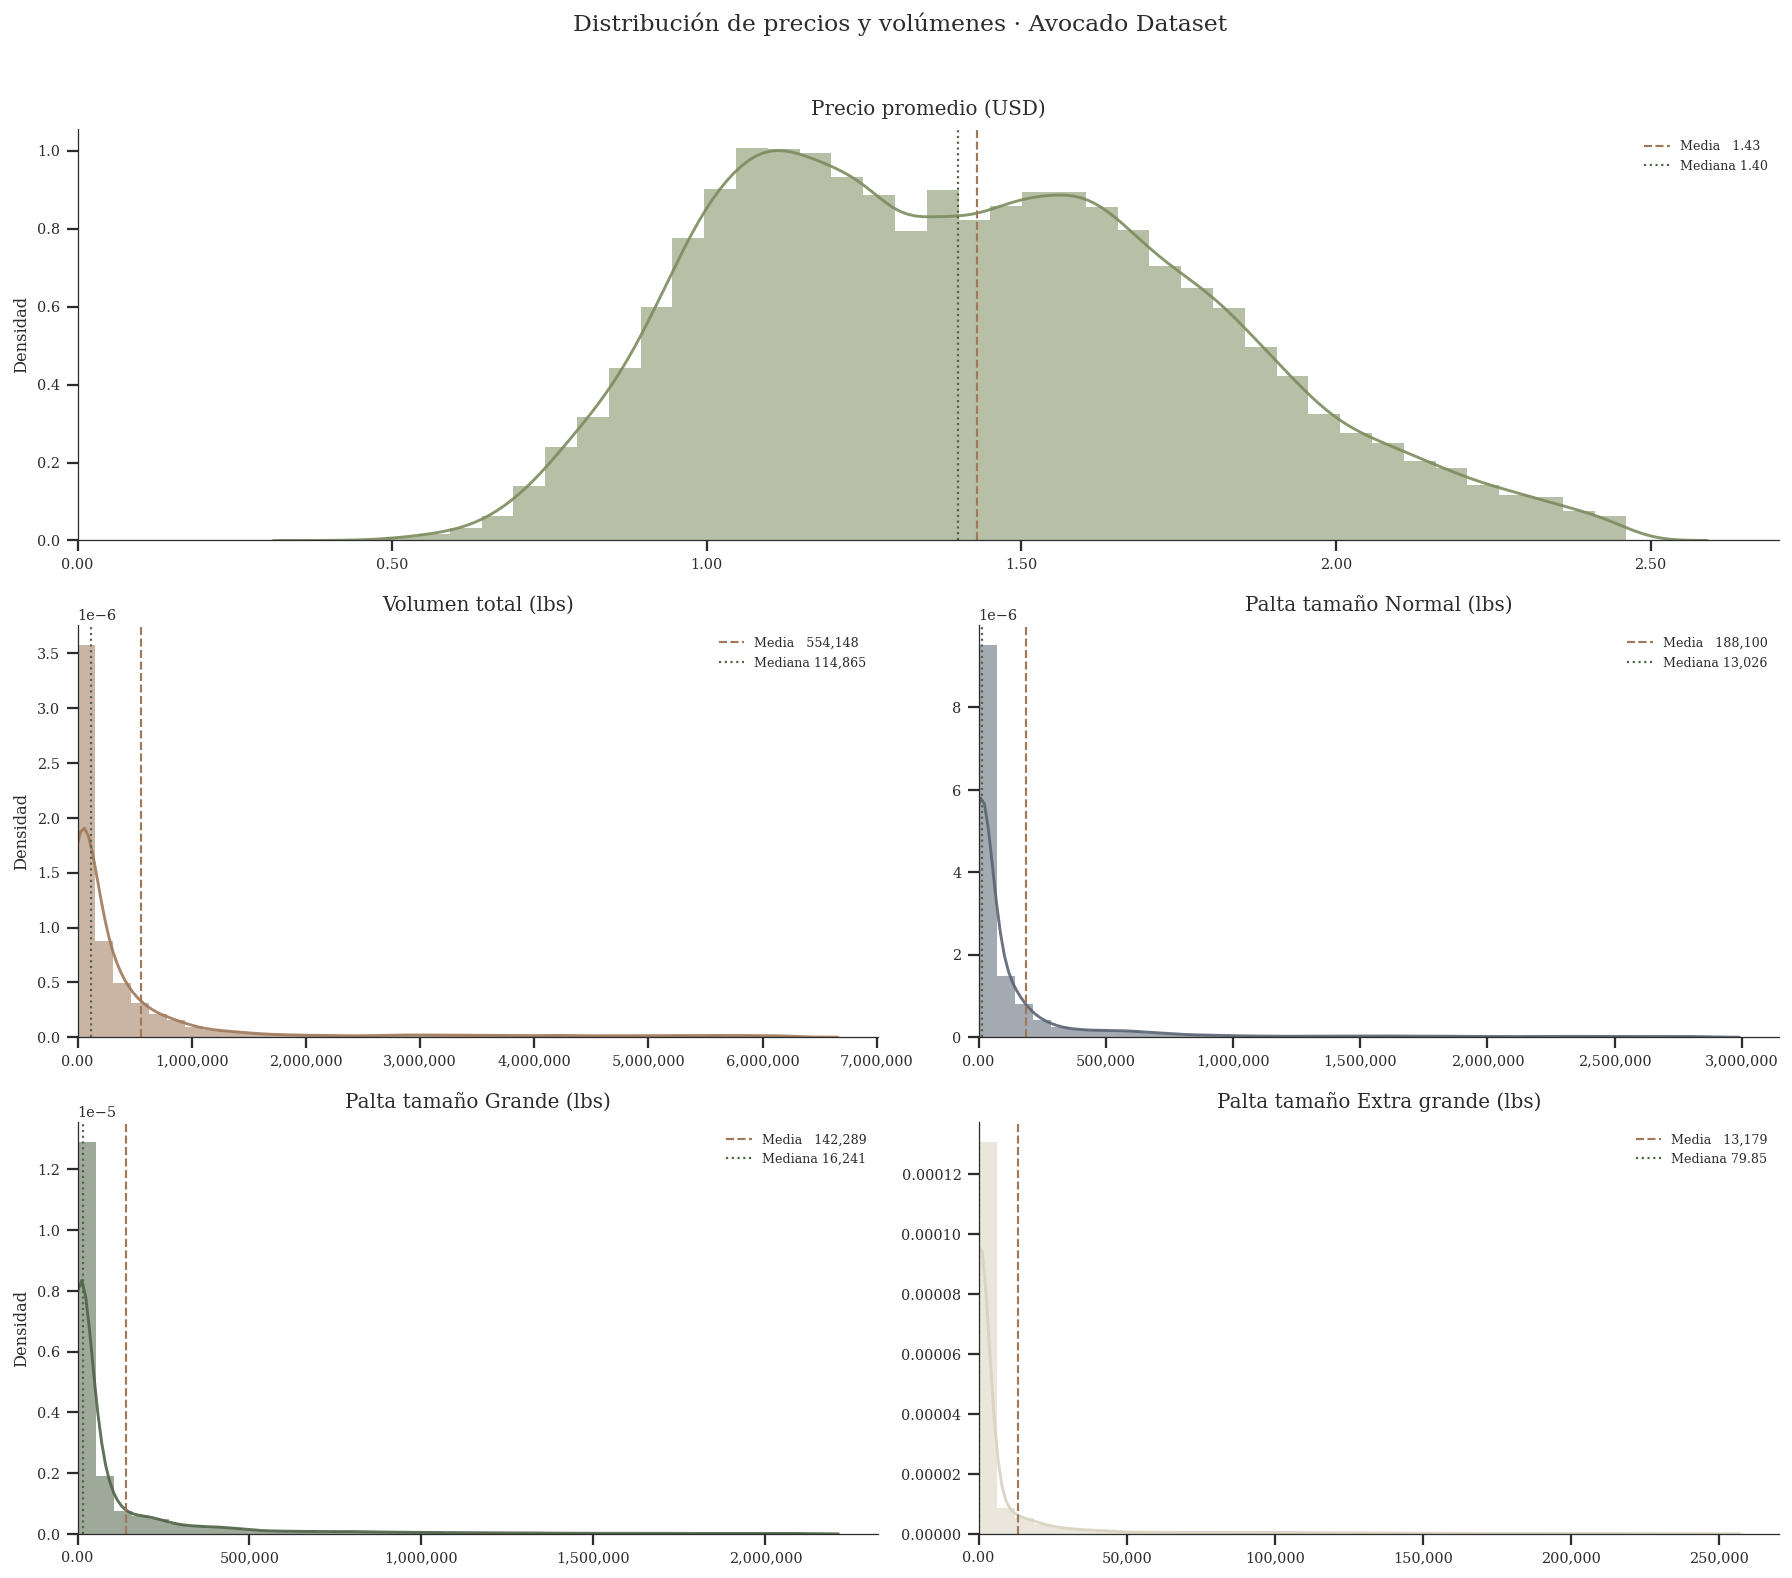

In [24]:
VARS_NUM = ['PrecioPromedio', 'TotalVolume', 'Palta_Normal', 'Palta_Grande', 'Palta_Extragrande']
TITULOS = {
    "PrecioPromedio":   "Precio promedio (USD)",
    "TotalVolume":      "Volumen total (lbs)",
    "Palta_Normal":     "Palta tamaño Normal (lbs)",
    "Palta_Grande":     "Palta tamaño Grande (lbs)",
    "Palta_Extragrande":"Palta tamaño Extra grande (lbs)",
}

# Layout 1-2-2
fig = plt.figure(figsize=(14, 12))
posiciones = [
    fig.add_subplot(3, 2, (1, 2)),  # fila 1: ocupa ambas columnas
    fig.add_subplot(3, 2, 3),
    fig.add_subplot(3, 2, 4),
    fig.add_subplot(3, 2, 5),
    fig.add_subplot(3, 2, 6),
]

for ax, var, color in zip(posiciones, VARS_NUM, COLORES_SEQ):

    serie = palta_full[var].dropna()
    p99   = serie.quantile(0.99)
    serie_clip = serie[serie <= p99]

    sns.histplot(
        serie_clip, ax=ax,
        color=color, alpha=0.55,
        bins=40, stat="density", linewidth=0,
    )
    sns.kdeplot(
        serie_clip, ax=ax,
        color=color, linewidth=1.6, alpha=0.9,
    )

    media   = serie.mean()
    mediana = serie.median()

    ax.axvline(media,   color=PALETA["tierra"], linewidth=1.2,
               linestyle="--", label=f"Media   {media:,.0f}" if media >= 1000 else f"Media   {media:.2f}")
    ax.axvline(mediana, color=PALETA["musgo"],  linewidth=1.2,
               linestyle=":",  label=f"Mediana {mediana:,.0f}" if mediana >= 1000 else f"Mediana {mediana:.2f}")

    ax.set_title(TITULOS[var], pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Densidad" if var in ["PrecioPromedio", "TotalVolume", "Palta_Grande"] else "")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
    ))
    ax.legend(loc="upper right", fontsize=7)
    ax.set_xlim(left=0)

fig.suptitle("Distribución de precios y volúmenes · Avocado Dataset",
             y=1.01, fontsize=13, color=PALETA["ink"])
sns.despine()
plt.tight_layout()
plt.savefig("visual/dist_numericas.png", bbox_inches="tight", dpi=150)
plt.show()

> ### Observaciones 

>**Precio promedio (USD)**
>La distribución es bimodal — tiene dos picos uno alrededor de USD 1.00 y otro alrededor de USD 1.50.
>Esto sugiere que el mercado opera en dos regímenes de precio distintos, probablemente asociados al tipo de palta (convencional vs. orgánica) o a la estacionalidad.
>La media (1.43) y la mediana (1.40) son muy cercanas, lo que indica una distribución relativamente simétrica en su centro. La cola derecha más larga — precios que llegan hasta USD 2.50 — refleja semanas o mercados puntuales de precio alto, posiblemente relacionados con escasez de oferta o picos de demanda.
>
>El rango más frecuente se concentra entre USD 1.00 y USD 1.75.
>
>**Volumen total y volúmenes por tamaño (PLU)**
>Los cuatro gráficos de volumen comparten el mismo patrón: distribuciones fuertemente sesgadas a la derecha, con la masa concentrada cerca de cero y colas muy largas. Esto se evidencia en la brecha pronunciada entre media y mediana en todos los casos:
**TotalVolume:** media 554,148 lbs vs. mediana 114,865 lbs — la media es casi 5 veces la mediana
**Palta_Normal (PLU 4046):** media 188,100 vs. mediana 13,026 — brecha aún más extrema
**Palta_Grande (PLU 4225):** media 142,289 vs. mediana 16,241
**Palta_Extragrande (PLU 4770):** media 13,179 vs. mediana 79.85 — caso extremo, la mediana casi en cero indica que en la mayoría de las regiones/semanas este tamaño directamente no se vendió o se vendió en volúmenes mínimos.
>
>
>Esto es esperable en datos de ventas retail: la mayoría de los registros son mercados pequeños o semanas de baja actividad, pero unos pocos mercados grandes (California, Northeast, etc.) concentran volúmenes enormes y jalan la media hacia arriba. La mediana es el estadístico más representativo del mercado típico en este caso.





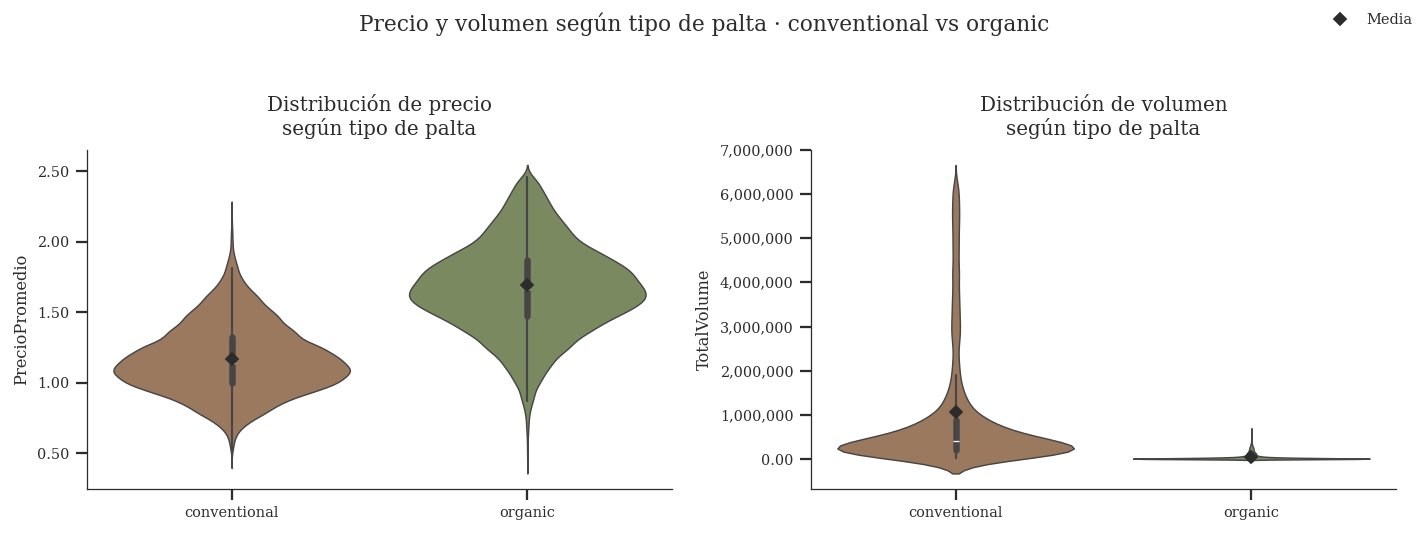

In [25]:
# Variable Categórica: Tipo (conventional / organic) 
# Violin plot comparativo — precio y volumen por tipo
# El violin muestra distribución completa; más informativo que un bar chart

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

VARS_CAT = ["PrecioPromedio", "TotalVolume"]
TITULOS_CAT = {
    "PrecioPromedio": "Distribución de precio\nsegún tipo de palta",
    "TotalVolume":    "Distribución de volumen\nsegún tipo de palta",
}
COLORES_TIPO = {
    "conventional": PALETA["tierra"],
    "organic":      PALETA["oliva"],
}

for ax, var in zip(axes, VARS_CAT):
    
    # Clip al p99 para no destruir la escala con outliers extremos
    p99 = palta_full[var].quantile(0.99)
    df_plot = palta_full[palta_full[var] <= p99].copy()
    
    sns.violinplot(
        data=df_plot,
        x="Tipo",
        y=var,
        ax=ax,
        palette=COLORES_TIPO,
        inner="box",       # muestra IQR y mediana adentro del violin
        linewidth=0.8,
        saturation=0.85,
        order=["conventional", "organic"],
    )
    
    # Superponer medias como puntos destacados
    for i, tipo in enumerate(["conventional", "organic"]):
        media = palta_full[palta_full["Tipo"] == tipo][var].mean()
        ax.plot(i, media, marker="D", color=PALETA["ink"],
                markersize=5, zorder=5, label="Media" if i == 0 else "")
    
    ax.set_title(TITULOS_CAT[var], pad=8)
    ax.set_xlabel("")
    ax.set_ylabel(var.replace("_", " "))
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}" if x >= 100 else f"{x:.2f}")
    )

# Leyenda manual unificada
linea_media = mlines.Line2D([], [], color=PALETA["ink"], marker="D",
                             markersize=5, linewidth=0, label="Media")
fig.legend(handles=[linea_media], loc="upper right", fontsize=8)

fig.suptitle("Precio y volumen según tipo de palta · conventional vs organic",
             y=1.02, fontsize=12, color=PALETA["ink"])
sns.despine()
plt.tight_layout()
plt.savefig("visual/dist_categorica_tipo.png", bbox_inches="tight", dpi=150)
plt.show()

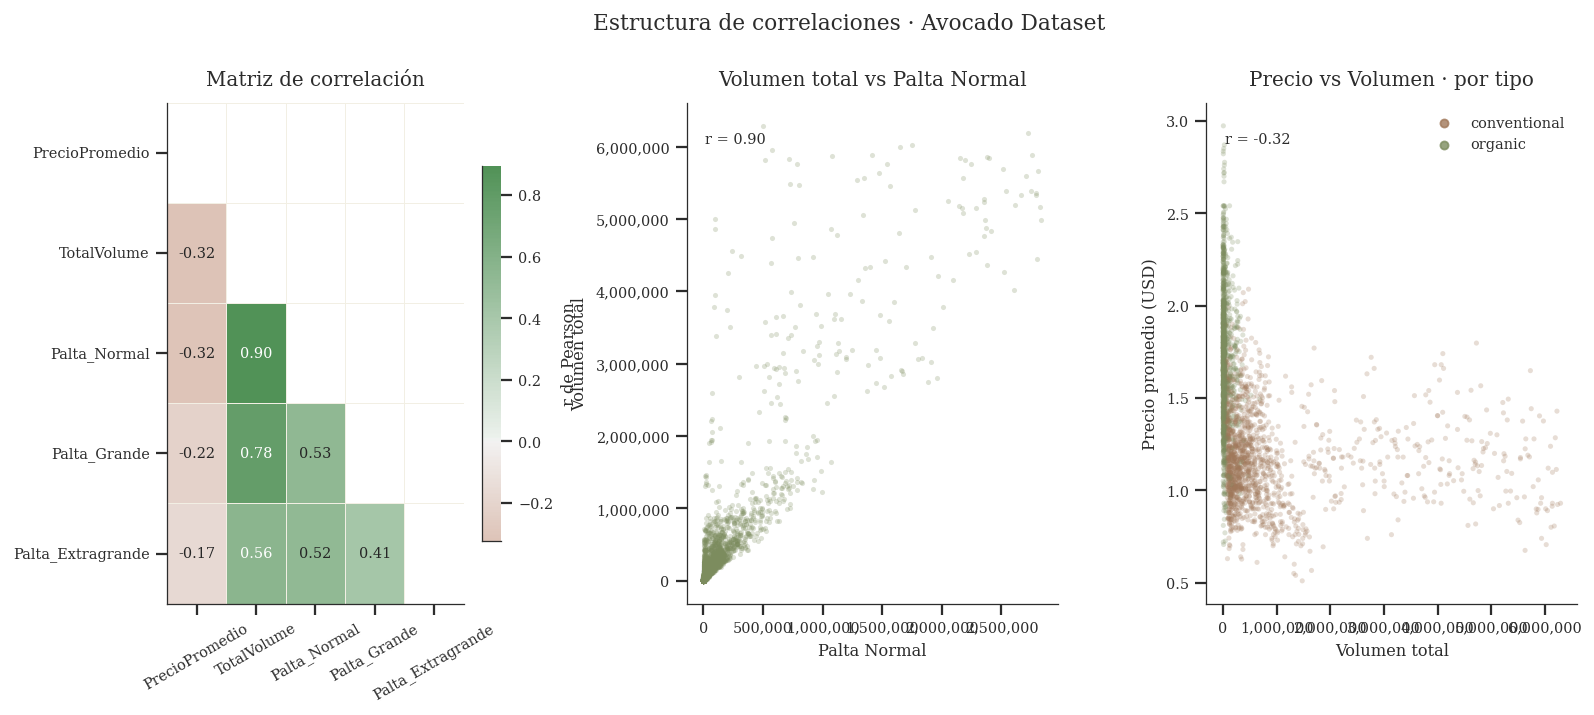

In [26]:
# ── CORRELACIÓN — Variables numéricas ────────────────────────────────────────
# Heatmap de matriz completa + scatter de pares clave

VARS_CORR = ["PrecioPromedio", "TotalVolume",
             "Palta_Normal", "Palta_Grande", "Palta_Extragrande"]

corr = palta_full[VARS_CORR].corr()

fig = plt.figure(figsize=(14, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.4)

ax_heat   = fig.add_subplot(gs[0, 0])
ax_sc1    = fig.add_subplot(gs[0, 1])
ax_sc2    = fig.add_subplot(gs[0, 2])

# ── Heatmap ───────────────────────────────────────────────────────────────────
mascara = np.triu(np.ones_like(corr, dtype=bool))   # solo triángulo inferior

sns.heatmap(
    corr,
    mask=mascara,
    ax=ax_heat,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(30, 130, s=60, l=55, as_cmap=True),  # tierra → oliva
    center=0,
    linewidths=0.4,
    linecolor=PALETA["hueso"],
    cbar_kws={"shrink": 0.75, "label": "r de Pearson"},
    annot_kws={"size": 8},
)
ax_heat.set_title("Matriz de correlación", pad=10)
ax_heat.tick_params(axis="x", rotation=30)
ax_heat.tick_params(axis="y", rotation=0)

# ── Scatter 1: TotalVolume vs Palta_Normal ────────────────────────────────────
# Par con correlación más alta — confirma que Normal domina el volumen
p99_x = palta_full["Palta_Normal"].quantile(0.99)
p99_y = palta_full["TotalVolume"].quantile(0.99)
df_sc = palta_full[
    (palta_full["Palta_Normal"]  <= p99_x) &
    (palta_full["TotalVolume"]   <= p99_y)
].sample(3000, random_state=42)   # muestra para no saturar el scatter

ax_sc1.scatter(
    df_sc["Palta_Normal"], df_sc["TotalVolume"],
    color=PALETA["oliva"], alpha=0.25, s=8, linewidths=0,
)
ax_sc1.set_xlabel("Palta Normal")
ax_sc1.set_ylabel("Volumen total")
ax_sc1.set_title("Volumen total vs Palta Normal", pad=10)
ax_sc1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_sc1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

r1 = corr.loc["TotalVolume", "Palta_Normal"]
ax_sc1.annotate(f"r = {r1:.2f}", xy=(0.05, 0.92),
                xycoords="axes fraction", fontsize=8, color=PALETA["ink"])

# ── Scatter 2: PrecioPromedio vs TotalVolume ──────────────────────────────────
# Relación inversa precio-volumen — el más interesante conceptualmente
p99_v = palta_full["TotalVolume"].quantile(0.99)
df_sc2 = palta_full[palta_full["TotalVolume"] <= p99_v].sample(3000, random_state=42)

colores_tipo = df_sc2["Tipo"].map({
    "conventional": PALETA["tierra"],
    "organic":      PALETA["oliva"],
})

ax_sc2.scatter(
    df_sc2["TotalVolume"], df_sc2["PrecioPromedio"],
    c=colores_tipo, alpha=0.25, s=8, linewidths=0,
)
ax_sc2.set_xlabel("Volumen total")
ax_sc2.set_ylabel("Precio promedio (USD)")
ax_sc2.set_title("Precio vs Volumen · por tipo", pad=10)
ax_sc2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

r2 = corr.loc["PrecioPromedio", "TotalVolume"]
ax_sc2.annotate(f"r = {r2:.2f}", xy=(0.05, 0.92),
                xycoords="axes fraction", fontsize=8, color=PALETA["ink"])

# Leyenda manual tipo
for tipo, color in [("conventional", PALETA["tierra"]), ("organic", PALETA["oliva"])]:
    ax_sc2.scatter([], [], color=color, s=20, label=tipo, alpha=0.8)
ax_sc2.legend(loc="upper right")

fig.suptitle("Estructura de correlaciones · Avocado Dataset",
             y=1.02, fontsize=12, color=PALETA["ink"])
sns.despine()
plt.savefig("visual/correlacion.png", bbox_inches="tight", dpi=150)
plt.show()

#### Observaciones: 

- Convencional: nube densa, volúmenes altísimos, precio bajo y estable (~1.0–1.5 USD). Comportamiento predecible.
- Orgánica: volúmenes cercanos a cero, precios dispersos hasta 3.0 USD. Alta variabilidad, poca masa de datos.

In [27]:
palta_1.to_csv("Datos/palta_1.csv", index=False)